In [1]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
from functools import partial
import numpy as np

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
## read in GACC level shapefiles

gsp = gpd.read_file("/home/jovyan/Preparedness_level/GACC_borders/National_GACC_Boundaries.shp")

In [3]:
## Get only the GACCs I want right now

gacc_list = ["NWCC",  "OSCC", "GBCC", "NRCC"] ## SWCC maybe too many false positives? Excluded: Rocky Mountains, Southern and Eastern (also HI and Ak). Southwest and NOrth California.  Included: Northwest,  Southern CA, Great Basin, Nothern Rockies.    
### Note: Northern CA seems to include HI and Pacific islands (american samoa and guam), so I excluded it. Also, the Southwest has weird island across texas. For now, excluded. "ONCC", "SWCC",


In [4]:
minx, miny, maxx, maxy = gsp[gsp.GACCAbbrev.isin(gacc_list)].total_bounds ## Just a big bbox of subset of GACCs I am looking at preliminarily
lon_bnds, lat_bnds = (minx, maxx), (miny, maxy)



def _preprocess(ds, lon_bounds, lat_bounds):
    x_min, x_max = min(lon_bounds), max(lon_bounds)
    y_min, y_max = min(lat_bounds), max(lat_bounds)
    x_slice = slice(x_min, x_max) 
    y_slice = slice(y_min, y_max)
    #selection = {"lon", "lat"}
    #selection["lon"] = x_slice
    #selection["lat"] = y_slice
    ds = ds.sel(lon = x_slice, lat = y_slice)
    return ds


partial_func = partial(_preprocess, lon_bounds=lon_bnds, lat_bounds=lat_bnds)

In [5]:
auth = earthaccess.login()

results = earthaccess.search_data(
    doi='10.5067/GPM/IMERGDF/DAY/07',
    temporal=("2016-05-01T00:00:00", "2016-10-01T12:00:00") # 1 year is ~ 8 GB of memory for read in, comparison, and plotting. # 2 years is  ~15GB. But thins really only shows sasonal cycles when you do the whole year. 
     ## Not using bounding box becuase just searches, and I know this is a dataset that has full coverage over CONUS
)

fn = earthaccess.open(results)

ds = xr.open_mfdataset(fn, preprocess = partial_func)

 

QUEUEING TASKS | :   0%|          | 0/2892 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2892 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2892 [00:00<?, ?it/s]

In [6]:
ds.rio.set_spatial_dims(y_dim = "lat", x_dim = "lon", inplace = True)

# print("Dataset bounds:", ds.rio.bounds())

# print("Polygon bounds:", polygons.total_bounds)

<xarray.Dataset> Size: 2GB
Dimensions:                         (time: 2892, lon: 282, lat: 165, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 23kB 2016-01-01 ......
  * lon                             (lon) float32 1kB -124.8 -124.7 ... -96.65
  * lat                             (lat) float64 1kB 32.55 32.65 ... 48.95
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 538MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    precipitation_cnt               (time, lon, lat) int8 135MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    precipitation_cnt_cond          (time, lon, lat) int8 135MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    MWprecipitation                 (time, lon, lat) float32 538MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    MWprecipitation_cnt             (time, lon, lat) int8 135MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    MWprecipitation_cnt_cond        (time, lon, lat) int8 135MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    randomError                     (time, lon, lat) float32 538MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    randomError_cnt                 (time, lon, lat) int8 135MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    probabilityLiquidPrecipitation  (time, lon, lat) int8 135MB dask.array<chunksize=(1, 282, 165), meta=np.ndarray>
    time_bnds                       (time, nv) datetime64[ns] 46kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    BeginDate:       2016-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2016-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2016-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20160101-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-19T00:38:32.331Z

In [7]:
ds.rio.write_crs("EPSG:4326", inplace=True)


gsp = gsp.to_crs("EPSG:4326")

ds.rio.set_spatial_dims(y_dim = "lat", x_dim = "lon", inplace = True)

ds['precipitation'].rio.set_spatial_dims(y_dim = "lat", x_dim = "lon", inplace = True)

<xarray.DataArray 'precipitation' (time: 2892, lon: 282, lat: 165)> Size: 538MB
dask.array<concatenate, shape=(2892, 282, 165), dtype=float32, chunksize=(1, 282, 165), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 23kB 2016-01-01 2016-01-02 ... 2023-12-01
  * lon          (lon) float32 1kB -124.8 -124.7 -124.6 ... -96.85 -96.75 -96.65
  * lat          (lat) float64 1kB 32.55 32.65 32.75 32.85 ... 48.75 48.85 48.95
    spatial_ref  int64 8B 0
Attributes:
    units:      mm/day
    long_name:  Daily mean precipitation rate (combined microwave-IR) estimat...

In [8]:
### For some reason there are multiple non-identical geometries for the same GACC, but no other difference I can see. I am going to just choose the top index.



#some_ids = gsp[gsp.GACCAbbrev.isin(gacc_list)].groupby("GACCAbbrev").GlobalID.max().reset_index()

gsp_sm = gsp[gsp.GACCAbbrev.isin(gacc_list)].dissolve(by='GACCAbbrev').reset_index()


In [9]:
## per GACC masking/ aggrigating

results = []

for index, row in gsp_sm.iterrows():
    # Extract the single geometry
    geom = [row['geometry']]
    
    # Clip the dataset to the exact polygon boundary.
    # pixels outside the polygon become NaN.
    # 'drop=True' shrinks the resulting array to the bounding box of the polygon.
    # ds_clipped = ds[['precipitation']].rio.clip(geom, ds.rio.crs, drop=True)

    ds_clipped = (
    ds['precipitation']
    .rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    .rio.clip(geom, ds.rio.crs, drop=True)
    )
    
    # Perform Spatial Aggregation
    # Now that it's clipped to the exact polygon, calculate the spatial mean
    # (ignoring the NaNs outside the polygon boundary)
    mean_for_polygon = ds_clipped.sum(dim=['lat', 'lon'], skipna=True)
    
    # Optional: Tag the result with an ID so you know which polygon it belongs to
    agg_for_polygon = mean_for_polygon.assign_coords(polygon_id=row.get('GACCAbbrev', index))
    
    results.append(agg_for_polygon)

# Combine the aggregated results back together (e.g., along a new 'polygon_id' dimension)
gp = xr.concat(results, dim="polygon_id")

gdf = gp.to_pandas().T

# Compute the final result to trigger the Dask execution
# final_values = final_aggregated_data.compute()

In [10]:
# Read in the IMSRs report datasets

imsr = pd.read_csv("/home/jovyan/Preparedness_level/IMRS_from_pub/gacc_activity.csv")
wf = pd.read_csv("/home/jovyan/Preparedness_level/IMRS_from_pub/wildfire_activity.csv")

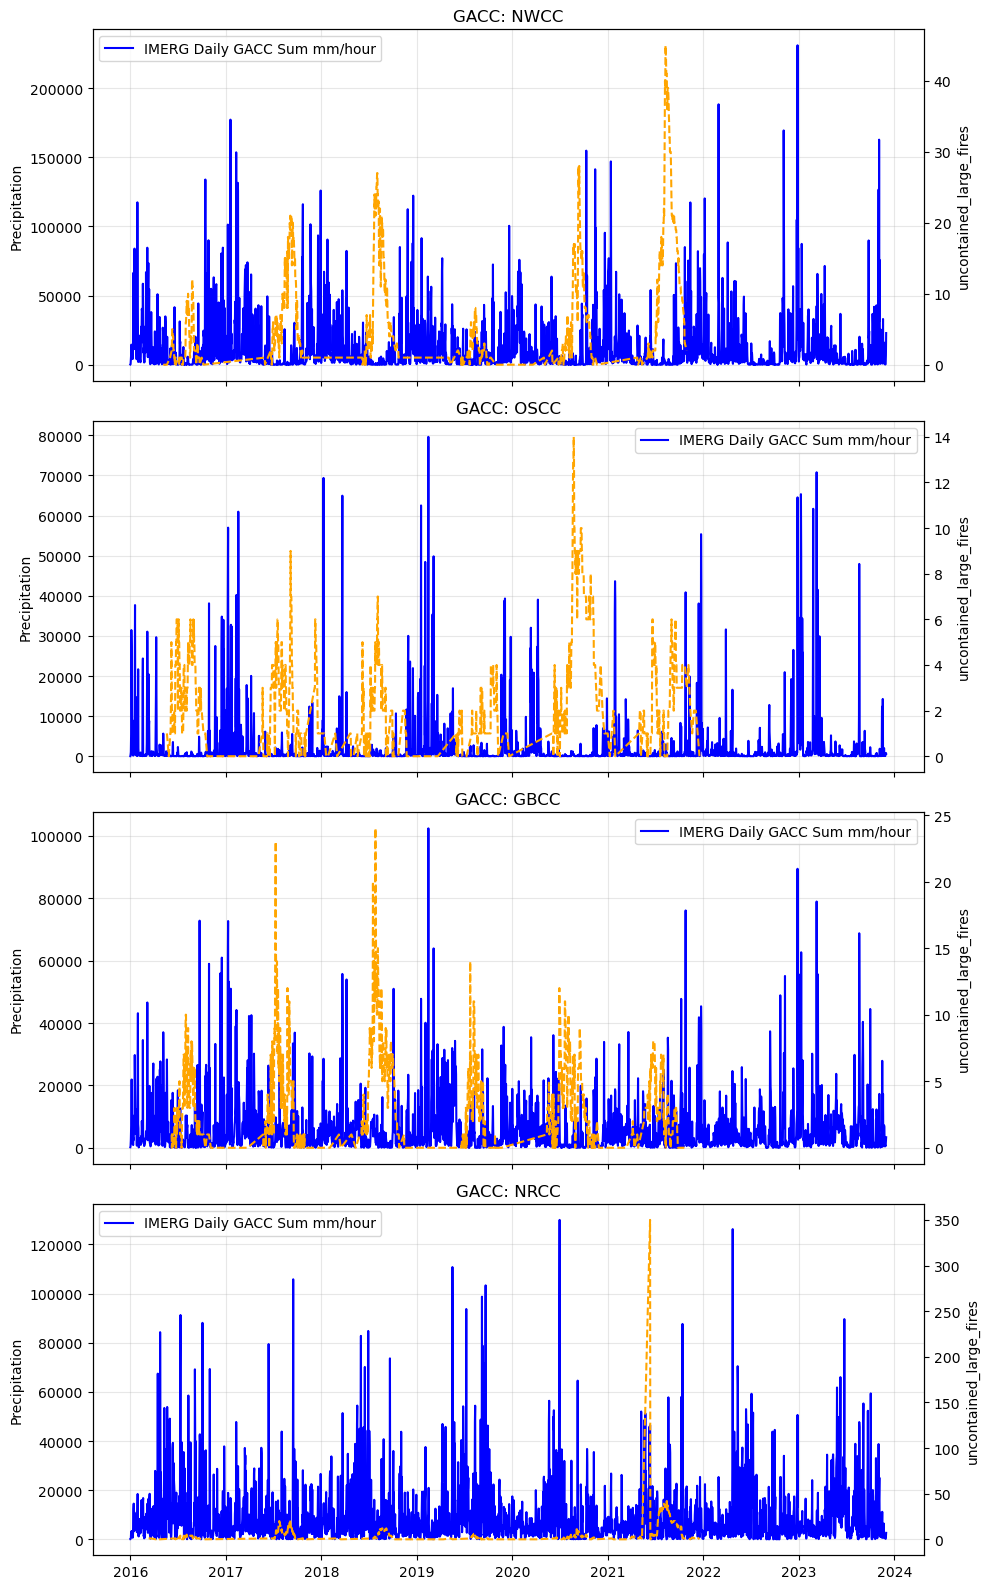

In [11]:
col = "uncontained_large_fires"
fig, axes = plt.subplots(
    nrows=len(gacc_list), 
    ncols=1, 
    figsize=(10, 4 * len(gacc_list)), 
    sharex=True
) 

# Handle the edge case where there is only 1 polygon (axes is not a list)
if len(gacc_list) == 1:
    axes = [axes]

# 4. Loop through each polygon ID and plot the data
for ax, poly_id in zip(axes, gacc_list):
    
    # Plot the aggregated cloud data from xarray
    ax.plot(gdf.index, gdf[poly_id], label='IMERG Daily GACC Sum mm/hour', color='blue')
    
    # Plot the reference data from your existing dataframe

    ax2 = ax.twinx()

    ax2.plot(
        imsr[(imsr.gacc == poly_id) & (imsr.imsr_date.astype("datetime64[ns]") <=  gdf.index.max()) & (imsr.imsr_date.astype("datetime64[ns]") >=  gdf.index.min())].imsr_date.astype("datetime64[ns]"), 
        imsr[(imsr.gacc == poly_id) & (imsr.imsr_date.astype("datetime64[ns]") <=  gdf.index.max()) & (imsr.imsr_date.astype("datetime64[ns]") >=  gdf.index.min())][col], 
        label='IMSR', 
        color='orange', 
        linestyle='--'
    )

    ax2.set_ylabel(col)
    # Formatting the subplot
    ax.set_title(f"GACC: {poly_id}")
    ax.set_ylabel("Precipitation")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Final formatting
plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [12]:
## Double check all the weird charactors in this dataset

wf
# Coerce to numeric; non-convertible values become NaN
coerced_series = pd.to_numeric(wf['fire_size'], errors='coerce')

# Filter the original DataFrame to show only the rows that became NaN
non_numeric_df = wf[coerced_series.isna()].fire_size.unique()

print(non_numeric_df)

['NR' nan '---']


In [13]:
### some groupby functions becuase the wildfire csv is on a perfire basis


def get_agg_fire(df):
    num_large_fires = df["fire_name"].nunique() # .nunique() is a built-in shortcut for len(.unique())
    df.loc[df["fire_size"] == "nan"] = np.nan
    df.loc[df["fire_size"] == "NR"] = np.nan
    df.loc[df["fire_size"] == "UNK"] = np.nan
    df.loc[df["fire_size"] == "---"] = np.nan ## Maybe this is wrong? COuld mean "same as time before". unclear
    cummulative_area = df["fire_size"].astype("float").sum()
    df.loc[df["percent_containment"] == "NR"] = np.nan
    df.loc[df["percent_containment"] == "UNK"] = np.nan
    df.loc[df["percent_containment"] == "---"] = np.nan
    
    cummulative_percent_containment = df["percent_containment"].astype("float").sum()
    df.loc[df["structures_lost"] == "NR"] = np.nan
    df.loc[df["structures_lost"] == "NA"] = np.nan
    df.loc[df["structures_lost"] == "UNK"] = np.nan
    df.loc[df["structures_lost"] == "---"] = np.nan
    num_struct = df["structures_lost"].astype("float").sum()
    
    # Return a Series; pandas will automatically convert the grouped Series into a DataFrame
    return pd.Series({
        "num_large_fires": num_large_fires, # 
        "num_new_fires": df[df.new_large_fire_mark == "*"].fire_name.nunique(),
        "cummulative_area": cummulative_area, 
        "cummulative_percent_containment": cummulative_percent_containment, 
        "cummulative_percent_containment_NN" : df[df.new_large_fire_mark != "*"].percent_containment.astype("float").sum(), 
        "cummulative_area_NN": df[df.new_large_fire_mark != "*"].fire_size.astype("float").sum(), 
        "num_struct": num_struct
    })

# as_index=False will automatically keep "gacc" and "imsr_date" as normal columns 
# instead of burying them in a MultiIndex.
wfg = wf.groupby(["gacc", "imsr_date"], as_index=False).apply(get_agg_fire)

In [14]:
wfg["average_percent_contaiment"] = wfg.cummulative_percent_containment/(wfg.num_large_fires)
wfg["contaiment_deficit"] = (wfg.num_large_fires * 100) -  wfg.cummulative_percent_containment # This 

wfg["average_percent_contaiment_NN"] = wfg.cummulative_percent_containment_NN/(wfg.num_large_fires - wfg.num_new_fires)


wfg["imsr_date"] = wfg.imsr_date.astype("datetime64[ns]")
wfg = wfg.sort_values(by = "imsr_date")

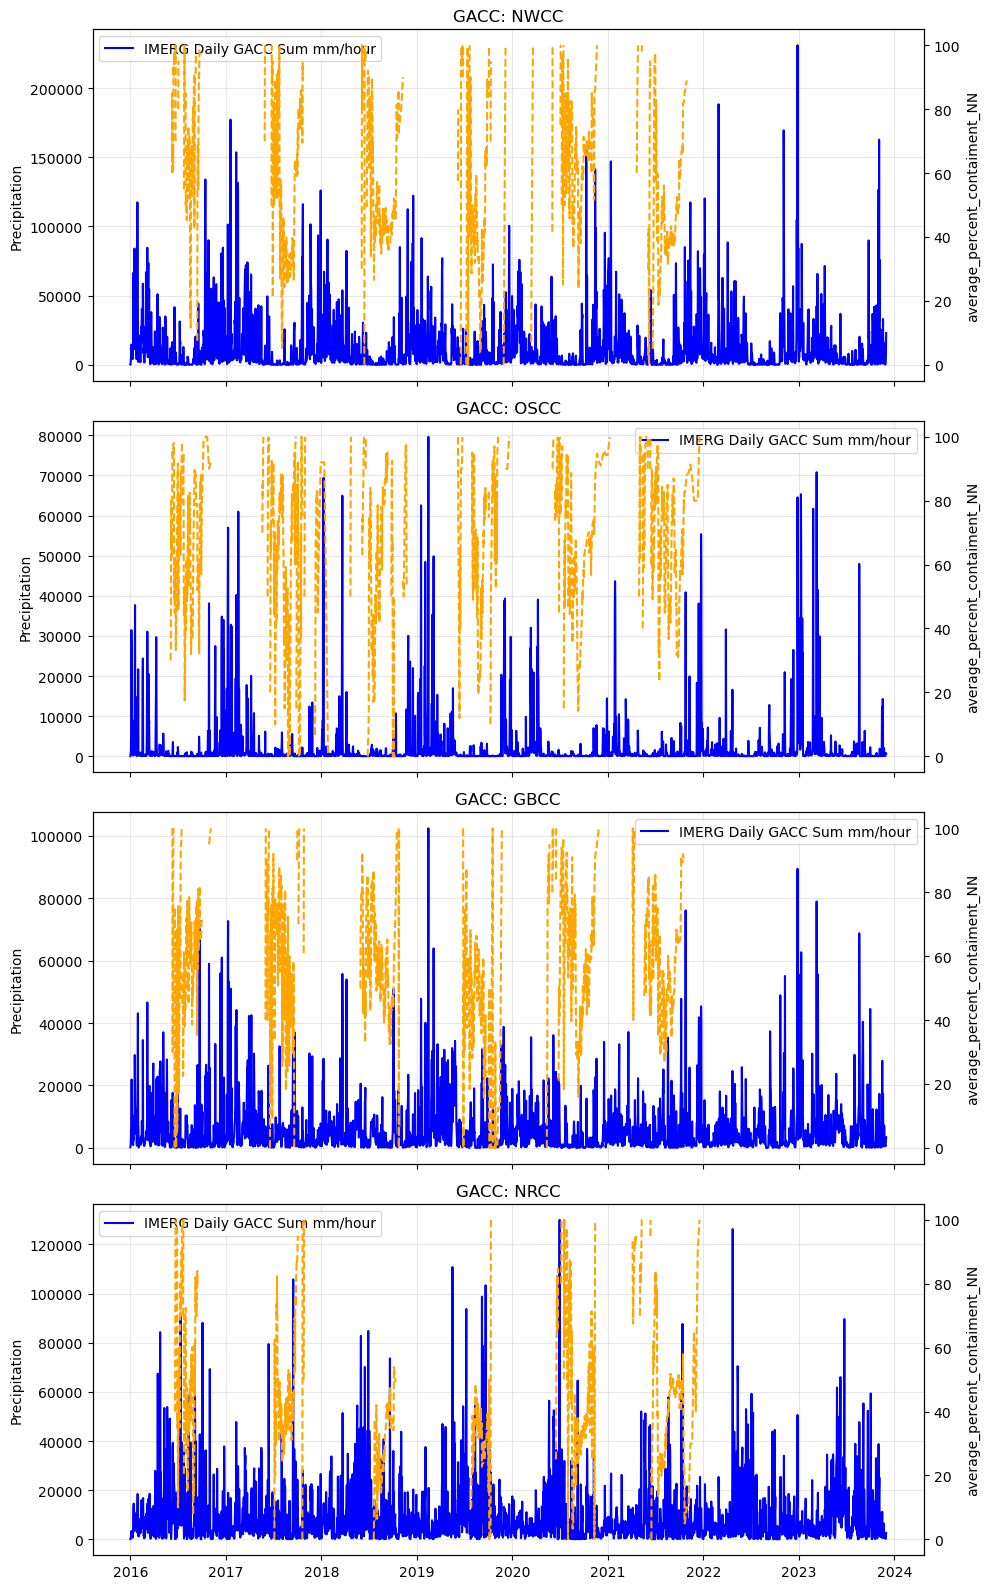

In [15]:
col = "average_percent_contaiment_NN"
fig, axes = plt.subplots(
    nrows=len(gacc_list), 
    ncols=1, 
    figsize=(10, 4 * len(gacc_list)), 
    sharex=True
) 

# Handle the edge case where there is only 1 polygon (axes is not a list)
if len(gacc_list) == 1:
    axes = [axes]

# 4. Loop through each polygon ID and plot the data
for ax, poly_id in zip(axes, gacc_list):
    
    # Plot the aggregated cloud data from xarray
    ax.plot(gdf.index, gdf[poly_id], label='IMERG Daily GACC Sum mm/hour', color='blue')
    
    # Plot the reference data from your existing dataframe

    ax2 = ax.twinx()
    sm = wfg[(wfg.gacc == poly_id) & (wfg.imsr_date.astype("datetime64[ns]") <=  gdf.index.max()) & (wfg.imsr_date.astype("datetime64[ns]") >=  gdf.index.min())]
    ax2.plot(
        wfg[(wfg.gacc == poly_id) & (wfg.imsr_date.astype("datetime64[ns]") <=  gdf.index.max()) & (wfg.imsr_date.astype("datetime64[ns]") >=  gdf.index.min())].imsr_date.astype("datetime64[ns]"), 
        wfg[(wfg.gacc == poly_id) & (wfg.imsr_date.astype("datetime64[ns]") <=  gdf.index.max()) & (wfg.imsr_date.astype("datetime64[ns]") >=  gdf.index.min())][col], 
        label='IMSR -- wildfire activity', 
        color='orange', 
        linestyle='--'
    )

    ax2.set_ylabel(col)
    # Formatting the subplot
    ax.set_title(f"GACC: {poly_id}")
    ax.set_ylabel("Precipitation")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Final formatting
plt.xlabel("Time")
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Percent Contrained')

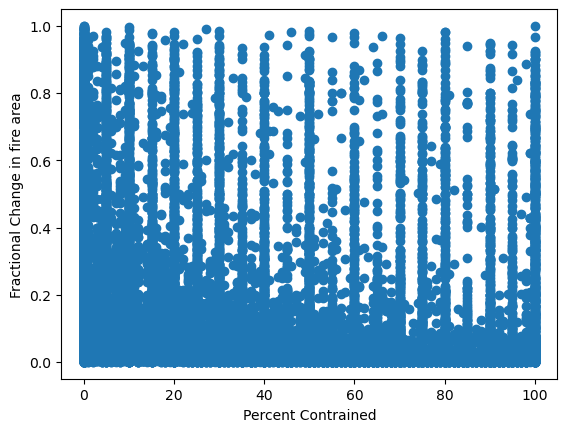

In [16]:
fire_size = pd.to_numeric(wf['fire_size'], errors='coerce')

fire_size_change = pd.to_numeric(wf['fire_size_change'], errors='coerce')
percent_containment = pd.to_numeric(wf['percent_containment'], errors='coerce')

mask = (~fire_size_change.isna()) & (~percent_containment.isna()) & (~fire_size.isna()) & (fire_size_change > 0) & (fire_size_change <= fire_size) & (fire_size > 988.4) ## Assuming in acers, this is 4 km^2


plt.scatter(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float") )
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contrained")

Text(0.5, 0, 'Percent Contained')

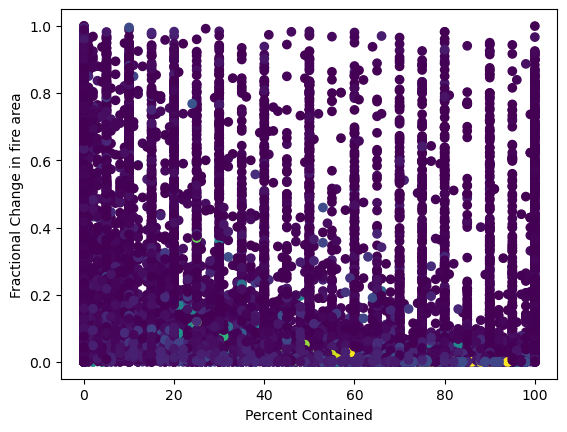

In [17]:
plt.scatter(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float"), c = wf[mask].fire_size.astype("float"))
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contained")

Text(0.5, 0, 'Percent Contained')

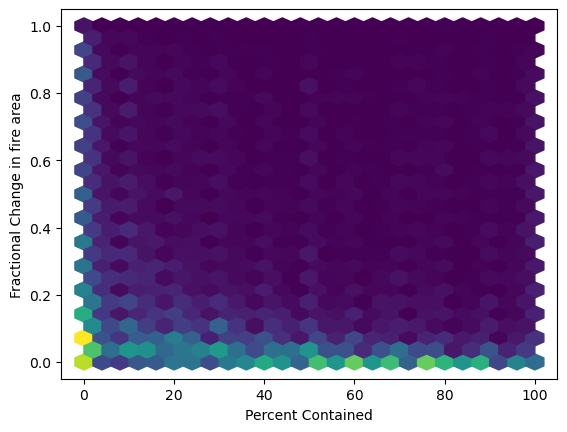

In [18]:
plt.hexbin(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float"), gridsize = 25)
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contained")